In [1]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from useful_functions import *
import pandas as pd
from joblib import Parallel, delayed


In [2]:
spectra_data    = fits.open('/Users/hyp0515/data/0715_Spring_BGS_ALL_trimmed.fits')
color_data      = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_with_Flux.fits')
cigale_data     = fits.open('/Users/hyp0515/data/IronPhysProp_v1.2_extracted.fits')
fastspecfit     = fits.open('/Users/hyp0515/data/0715_Spring_half_BGS_BRIGHT_catalog_fastspecfit.fits')

ids = read_ids('dp_samples_ids.txt')

SPECTRA = Spectrum(spectra_data, cigale_data, fastspecfit, load_targetID=ids)


In [3]:
SPECTRA.stack_data()
SPECTRA.mask_bad()

In [4]:
FIT     = FitSpectrum()
SPECTRA = FIT.shift_to_rest_frame(SPECTRA)
SPECTRA = FIT.label_emission_lines(SPECTRA, 3)
print(SPECTRA.n_spectra)

21454


In [5]:
idx = np.random.choice(SPECTRA.n_spectra, size=1, replace=False)[0]
id = SPECTRA.targetID[idx]
# id = 39627788226921902
# idx = SPECTRA.id2index(id)
spectrum_link(id)

'https://www.legacysurvey.org/viewer/desi-spectrum/dr1/targetid39627824235025269'

In [6]:
SPECTRA.df[SPECTRA.df['TARGETID'] == id]

,TARGETID,RA,DEC,SPECTYPE,LOGM,LOGSFR,z_pipe,z,OII,Hbeta,OIII,Halpha,NII,SII
20990,39627824235025269,194.982521,1.462967,GALAXY,10.548396,0.817736,0.202818,0.202818,True,True,False,True,True,True


In [7]:
lam, flux, ivar, conti, emission = SPECTRA.data_stack[idx, 0, :], SPECTRA.data_stack[idx, 1, :], SPECTRA.data_stack[idx, 2, :], SPECTRA.data_stack[idx, 4, :], SPECTRA.data_stack[idx, 5, :]
sigma = 1/np.sqrt(np.abs(ivar))

In [8]:
params_1comp, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=False, w_dz=False)
model_1comp = np.sum([
            model_vel(lam, gaussian_parms=params_1comp['gaussian_params'][i]) 
            for i in range(len(slice_indices)+1)
        ], axis=0)
residual_1comp = flux - model_1comp

chisq_1comp = np.sum((residual_1comp/sigma)**2)
dof_1comp = len(lam) - (1+n_lines_fit)



params_2comp, (combine_lam, combine_flux, combine_sigma), slice_indices, n_lines_fit = FIT.fit_multi_emission_vel(SPECTRA, id=id, two_component=True, w_dz=False)
model_2comp = np.sum([
    model_vel(lam, gaussian_parms=params_2comp['gaussian_params'][i]) for i in range(len(slice_indices)+1)
], axis=0)

left_2comp = np.sum([
    model_vel(lam, gaussian_parms=params_2comp['left_comp'][i]) for i in range(len(slice_indices)+1)
], axis=0)
left_2comp = np.sum([
    model_vel(lam, gaussian_parms=params_2comp['left_comp'][i]) for i in range(len(slice_indices)+1)
], axis=0)

right_2comp = np.sum([
    model_vel(lam, gaussian_parms=params_2comp['right_comp'][i]) for i in range(len(slice_indices)+1)
], axis=0)

residual_2comp = flux - model_2comp
chisq_2comp = np.sum((residual_2comp/sigma)**2)
dof_2comp = len(lam) - (4+n_lines_fit*2)


F_stat = ((chisq_1comp - chisq_2comp) / (dof_1comp - dof_2comp)) / (chisq_2comp / dof_2comp)
p_value = 1 - f.cdf(F_stat, dof_1comp - dof_2comp, dof_2comp)
print(chisq_1comp/dof_1comp)
print(chisq_2comp/dof_2comp)
print(p_value)

1.1661360855935392
1.1196428845862942
1.1102230246251565e-16


In [9]:
print(params_2comp['dv'])
print(params_2comp['dv'][0]-params_2comp['dv'][1])
print(params_2comp['sigma'])
print(1.5*np.sum(params_2comp['sigma']))

(np.float64(91.51576112766254), np.float64(-60.34571066390706))
151.8614717915696
(np.float64(27.769297855504306), np.float64(71.36615949576522))
148.7031860269043


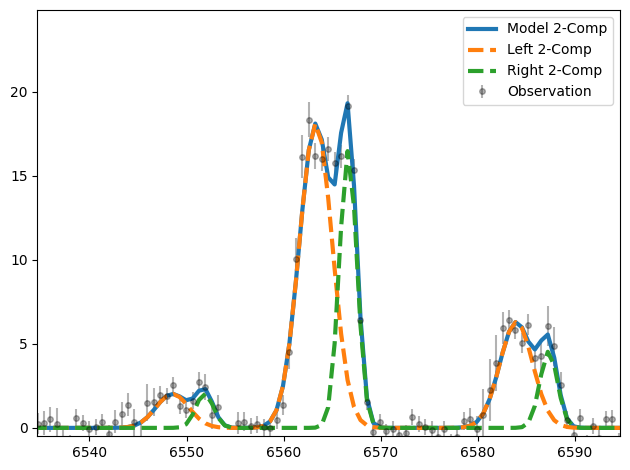

(7781,)


In [ ]:
plt.errorbar(lam, flux, yerr=sigma, label='Observation', fmt='o', color='k', markersize=4, alpha=0.3)
# plt.plot(lam, emission, label='Emission')
# plt.plot(lam, model_1comp, label='Model 1-Comp', linewidth=3)
plt.plot(lam, model_2comp, label='Model 2-Comp', linewidth=3)
plt.plot(lam, left_2comp, label='Left 2-Comp', linestyle='--', linewidth=3)
plt.plot(lam, right_2comp, label='Right 2-Comp', linestyle='--', linewidth=3)
# plt.plot(lam, 3*sigma, label='3 Sigma')
plt.xlim([Halpha_rest[0]-30, Halpha_rest[0]+30])
# plt.xlim([Hbeta_rest[0]-50, Hbeta_rest[0]+50])
# plt.xlim([OII_rest[0]-50, OII_rest[1]+50])
# plt.xlim([OIII_rest[0]-50, OIII_rest[1]+50])
plt.ylim(bottom=-0.5, top=np.max(flux[(lam<plt.xlim()[1])&(lam>plt.xlim()[0])])*1.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# def process_target(target_id):
#     """
#     Processes a single target to find double-peaked features.
#     """
#     p_value, delta_dv, dp_detection, line_fluxes_rank, params_2comp = FIT.find_dp(SPECTRA, id=target_id)

#     dp_cols = ['OII3726_dp', 'OII3729_dp',
#             'Hbeta_dp',
#             'OIII4959_dp', 'OIII5007_dp',
#             'NII6548_dp', 'Halpha_dp', 'NII6583_dp', 
#             'SII6716_dp', 'SII6731_dp']

#     dp_rank_cols = [f'{col[:-3]}_rank' for col in dp_cols]

#     data = {
#         'TARGETID': target_id,
#         'p_value': p_value,
#         'dv': params_2comp['dv'],
#         'delta_dv': delta_dv,
#         'sigma': params_2comp['sigma'],
#     }
#     data.update(dict(zip(dp_cols, dp_detection)))
#     data.update(dict(zip(dp_rank_cols, line_fluxes_rank)))
#     return data


# results = Parallel(n_jobs=10)(delayed(process_target)(target_id) for target_id in tqdm(SPECTRA.targetID))

# dp_df = pd.DataFrame(results)

# # display(dp_df)

  3%|▎         | 570/21454 [00:10<02:53, 120.21it/s]

KeyboardInterrupt: 